### FASE 3. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis Exploratorio de Datos — Ingresos totales por ventas a clientes de un comercio.

**Objetivo de esta fase:**
Comprender el comportamiento de los datos mediante estadísticas descriptivas y visualizaciones, identificando patrones, relaciones entre variables y, especialmente, qué factores se asocian a que un cliente (variable `ìd_cliente`) que realiza una compra (variable `order_id`).

**Punto de partida:** `02_datos_limpios.csv` (52.000 filas × 39 columnas), resultado de la Fase 2.

**Flujo que seguiremos:**
1. Recordatorio Pre-EDA.
2. Identificar variables categóricas y numéricas.
3. Análisis univariante (categóricas y numéricas).
4. Análisis bivariante — relación con la variable objetivo `y`.
5. Relación entre variables numéricas y correlaciones globales.
6. Evolución temporal.
7. Preguntas de negocio.
8. Conclusiones de la fase.


In [1]:
# Libreria de Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Exploracion de Archivos de soporte
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se

# Para que se muestren todas las columnas al imspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

In [56]:
def exploracion(df, n=3):

    print('PRIMERAS COLUMNAS')
    display(df.sample(n).T)
    print(":" * 100)
    print('INBORMACIÓN BÁSICA')
    display(df.info())
    print(":" * 100)
    print('ESTADISTICOS')
    display(df.describe(include="all").T)
    print(":" * 100)
    print('TAMAÑO DATAFRAME')
    print(df.shape)
    print(":" * 100)
    print('NULOS')
    display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
    print(":" * 100)
    print('PORCENTAJE DE NULOS')
    display((df.isna().mean()[df.isna().mean() > 0] * 100).sort_values(ascending=False).round(2))
    print(":" * 100)
    print('DUPLICADOS')
    print(df.duplicated().sum())
    

In [57]:
exploracion(df)

PRIMERAS COLUMNAS


,11952,12883,21034
order_id,11953,12884,21035
id_cliente,bd789c8d-1f8e-4496-89dc-3c87d3e8c803,a635d738-cb6d-4705-acf3-6c3b17a8eb8c,af4b5a7b-9110-4f9f-8201-6f714c3cf5ed
product_id,P0020,P0072,P0033
fecha_pedido,2022-10-08 00:00:00,2022-07-18 00:00:00,2023-04-28 00:00:00
cantidad,1,3,1
precio_unitario,36.36,88.91,97.9
descuento,0.15,0.0,0.05
importe_total,30.91,266.73,93.01
metodo_pago,tarjeta de debito,tarjeta de credito,tarjeta de credito
envio_gratis,no,no,si


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
INBORMACIÓN BÁSICA
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  52000 non-null  int64         
 1   id_cliente                52000 non-null  str           
 2   product_id                52000 non-null  str           
 3   fecha_pedido              52000 non-null  datetime64[us]
 4   cantidad                  52000 non-null  int64         
 5   precio_unitario           52000 non-null  float64       
 6   descuento                 52000 non-null  float64       
 7   importe_total             52000 non-null  float64       
 8   metodo_pago               52000 non-null  str           
 9   envio_gratis              52000 non-null  str           
 10  calificacion              52000 n

None

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
ESTADISTICOS


...

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
TAMAÑO DATAFRAME
(52000, 39)
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
NULOS


fecha_registro    253
dtype: int64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
PORCENTAJE DE NULOS


fecha_registro    0.49
dtype: float64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
DUPLICADOS
0


In [49]:
valores_claves=['order_id','id_cliente']

In [58]:
def comprobar_claves(df, valores_claves):

    for clave in valores_claves:
        print('Valores claves:')
        print(f'{clave}: {df[clave].duplicated().sum()} duplicados')
        print(f'{clave}: {df[clave].nunique()} unicos')
        print('=' * 100)
    

In [52]:
comprobar_claves(df,valores_claves)

Valores claves:
order_id: 0 duplicados
order_id: 52000 unicos
Valores claves:
id_cliente: 44013 duplicados
id_cliente: 7987 unicos


##### CREAR TABLA CLIENTES

In [61]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ingresos_anuales=('ingresos_anuales', 'first')
    ).reset_index()

clientes

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ingresos_anuales
0,00047a8c-eaed-4e09-a302-4081b07e37f9,6,582.25,44.0,barcelona,corporativo,41626
1,0005530b-bb59-4862-9ed1-9ba4b57e4b95,8,714.03,64.0,granada,recurrente,64957
2,000c848f-a5fc-40a5-a3ba-3de5a7e12089,1,9.49,40.0,sevilla,nuevo,37981
3,0013343e-3a60-417d-bad5-88780f5a83a1,4,520.32,34.0,murcia,corporativo,61224
4,0030dae9-1d2a-4aaf-ba17-c19d34228fbc,3,193.17,48.0,vigo,recurrente,24208
...,...,...,...,...,...,...,...
7982,ffe3fcfa-07c0-42c4-b97c-52ab6efac87a,1,110.87,22.0,vigo,nuevo,72177
7983,ffe5e4a4-9512-4bbd-98f9-75a00a28f4ce,5,648.41,31.0,zaragoza,nuevo,38826
7984,ffea67ee-8438-441c-b8a0-5c0ff886b034,3,175.72,47.0,sevilla,nuevo,35518
7985,fff01d47-aae0-4ce5-847d-aea0a915c59d,9,546.42,35.0,malaga,recurrente,30258


##### ESTUDIO PREVIO SIN Cols_excluir

In [71]:
def eda(df, n=2, cols_excluir=None):
    """
    Funcion que proporciona un EDA rapido.
    
    Parameters
    ----------
    df : DataFrame
        DataFrame que queremos analizar.
        
    n : int
        Numero de decimales para las estadisticas numericas.
        
    cols_excluir : list
        Lista de columnas que no queremos analizar.
    """

    # Si no indicamos columnas a excluir,
    # creamos una lista vacia
    if cols_excluir is None:
        cols_excluir = []

    # Creamos un DataFrame sin las columnas excluidas
    df_eda = df.drop(columns=cols_excluir, errors="ignore")

    # --------------------------------------------------
    # IDENTIFICACION DE TIPOS DE COLUMNAS
    # --------------------------------------------------

    num_cols = df_eda.select_dtypes(
        include="number"
    ).columns

    cat_cols = df_eda.select_dtypes(
        include=["string", "category", "object"]
    ).columns

    date_cols = df_eda.select_dtypes(
        include=["datetime", "datetimetz"]
    ).columns

    # Mostramos las columnas encontradas
    print("Variables numéricas:\n\n", num_cols)
    print('=' * 100)

    print("\nVariables categóricas:\n\n", cat_cols)
    print('=' * 100)

    print("\nVariables datetime:\n\n", date_cols)

    # --------------------------------------------------
    # ESTADISTICAS BASICAS
    # --------------------------------------------------

    print("\n========== ESTADÍSTICAS BÁSICAS ==========\n")

    # Variables numericas
    if len(num_cols) > 0:

        print("Variables numéricas:")

        print(
            df_eda[num_cols]
            .describe()
            .T
            .round(n)
        )

    # Variables categoricas
    if len(cat_cols) > 0:

        print("\nVariables categóricas:")

        print(
            df_eda[cat_cols]
            .describe()
            .T
        )

    # Variables datetime
    if len(date_cols) > 0:

        print("\nVariables datetime:")

        print(
            df_eda[date_cols]
            .describe()
            .T
        )

    # --------------------------------------------------
    # ANALISIS DE VARIABLES CATEGORICAS
    # --------------------------------------------------

    if len(cat_cols) > 0:

        print(
            "\n========== ANALISIS DE VARIABLES CATEGORICAS ==========\n"
        )

        for col in cat_cols:

            print(
                f"\n----------- ESTAMOS ANALIZANDO: '{col}' ----------\n"
            )

            print("Valores únicos:")

            print(
                df_eda[col].unique()
            )

            print("\nFrecuencia de los valores:")

            print(
                df_eda[col].value_counts()
            )

    # --------------------------------------------------
    # COUNTPLOT
    # --------------------------------------------------

    if len(cat_cols) > 0:
        
        print(
    "\n============== COUNTPLOT ==============\n"
    "(REPRESENTACIÓN DE UNIVARIABLES CATEGÓRICAS)"
)

        # Si tiene demasiadas categorias,
        # no hacemos el grafico
        cat_cols_plot = [
            col for col in cat_cols
            if df_eda[col].nunique() <= 200
        ]

        # Mostramos las columnas que no se van a representar
        for col in cat_cols:

            if df_eda[col].nunique() > 200:

                print(
                    f"Columna {col} tiene demasiadas "
                    f"categorias: {df_eda[col].nunique()}"
                )

        # Creamos los graficos solo si hay columnas que representar
        if len(cat_cols_plot) > 0:

            n_graficos = len(cat_cols_plot)
            ncols = 2
            nrows = (n_graficos + ncols - 1) // ncols

            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=(8 * ncols, 5 * nrows)
            )

            axes = np.atleast_1d(axes).flatten()

            for ax, col in zip(axes, cat_cols_plot):

                sns.countplot(
                    x=df_eda[col],
                    order=df_eda[col].value_counts().index,
                    ax=ax
                )

                ax.set_title(f"Distribución de {col}")
                ax.tick_params(axis="x", rotation=90)

            # Ocultamos ejes sobrantes
            for ax in axes[n_graficos:]:
                ax.set_visible(False)

            plt.tight_layout()
            plt.show()

    # --------------------------------------------------
    # HISTOGRAMAS
    # --------------------------------------------------

    if len(num_cols) > 0:
        print(
            "\n============== HISTOGRAMAS ==============\n"
            "(REPRESENTACION DE UNIVARIABLES NUMERICAS):"
        )

        n_graficos = len(num_cols)
        ncols = 3
        nrows = (n_graficos + ncols - 1) // ncols

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(5 * ncols, 3.5 * nrows)
        )

        axes = np.atleast_1d(axes).flatten()

        for ax, col in zip(axes, num_cols):

            sns.histplot(
                df_eda[col],
                bins=20,
                ax=ax
            )

            ax.set_title(col)

        # Ocultamos ejes sobrantes
        for ax in axes[n_graficos:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # BOXPLOTS
    # --------------------------------------------------

    if len(num_cols) > 0:
        
        print(
            "\n============== BOXPLOTS ==============\n"
            "(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)"
        )

        n_graficos = len(num_cols)
        ncols = 1
        nrows = (n_graficos + ncols - 1) // ncols

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(10 * ncols, 2 * nrows)
        )

        axes = np.atleast_1d(axes).flatten()

        for ax, col in zip(axes, num_cols):

            sns.boxplot(
                x=df_eda[col],
                ax=ax
            )

            ax.set_title(col)

        # Ocultamos ejes sobrantes
        for ax in axes[n_graficos:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()



Variables numéricas:

 Index(['order_id', 'cantidad', 'precio_unitario', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'latitude', 'longitude', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

Variables categóricas:

 Index(['id_cliente', 'product_id', 'metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'nombre_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

Variables datetime:

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

Variables numéricas:
                            count      mean       std       min       25%       50%       75%        max
order_id                  52000.0  26000.50  15011.25      1.00  13000.7

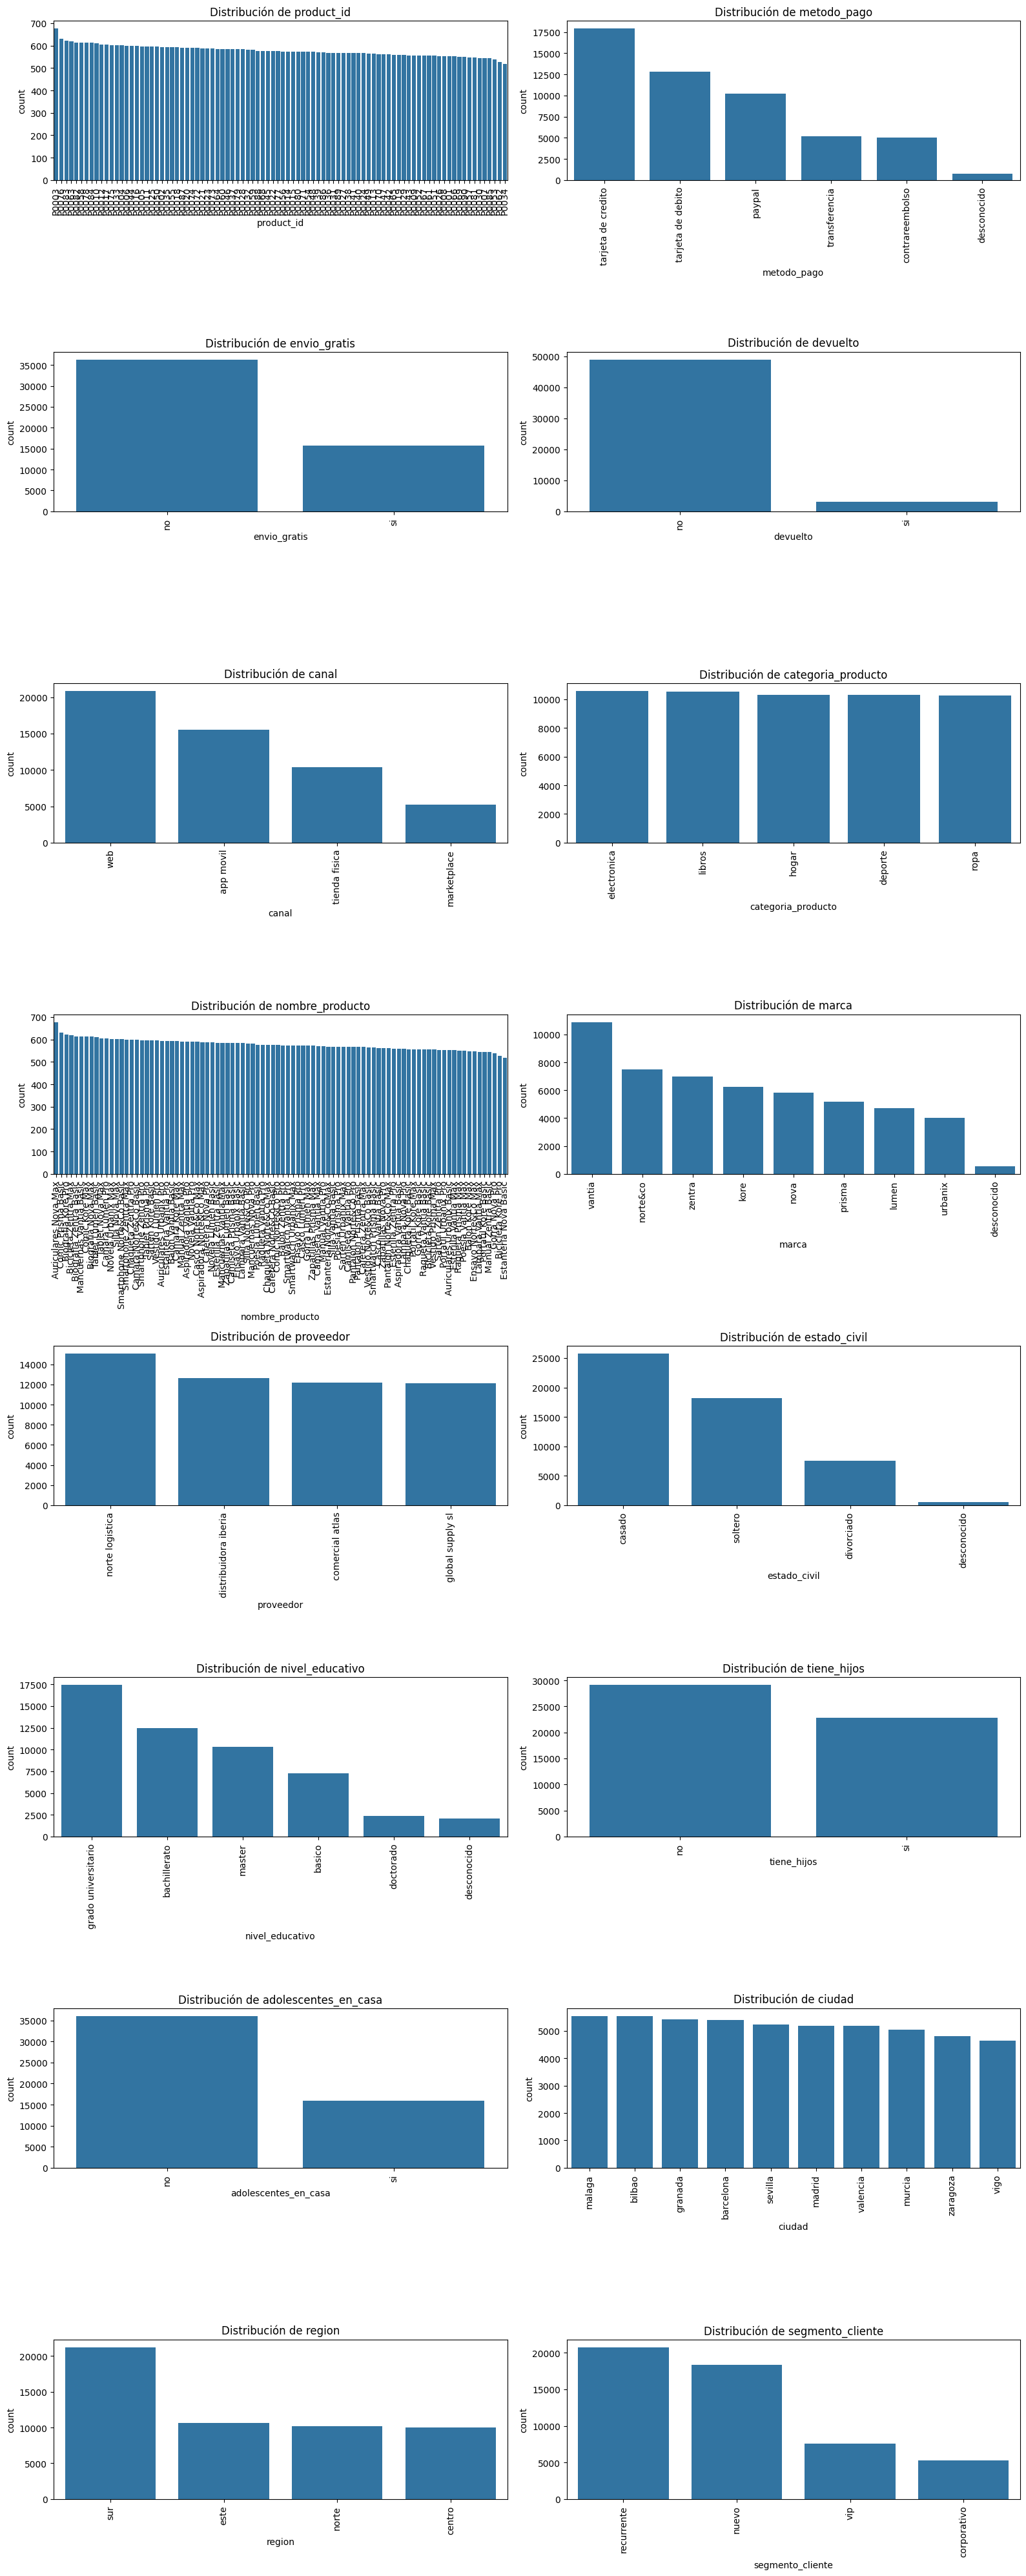


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


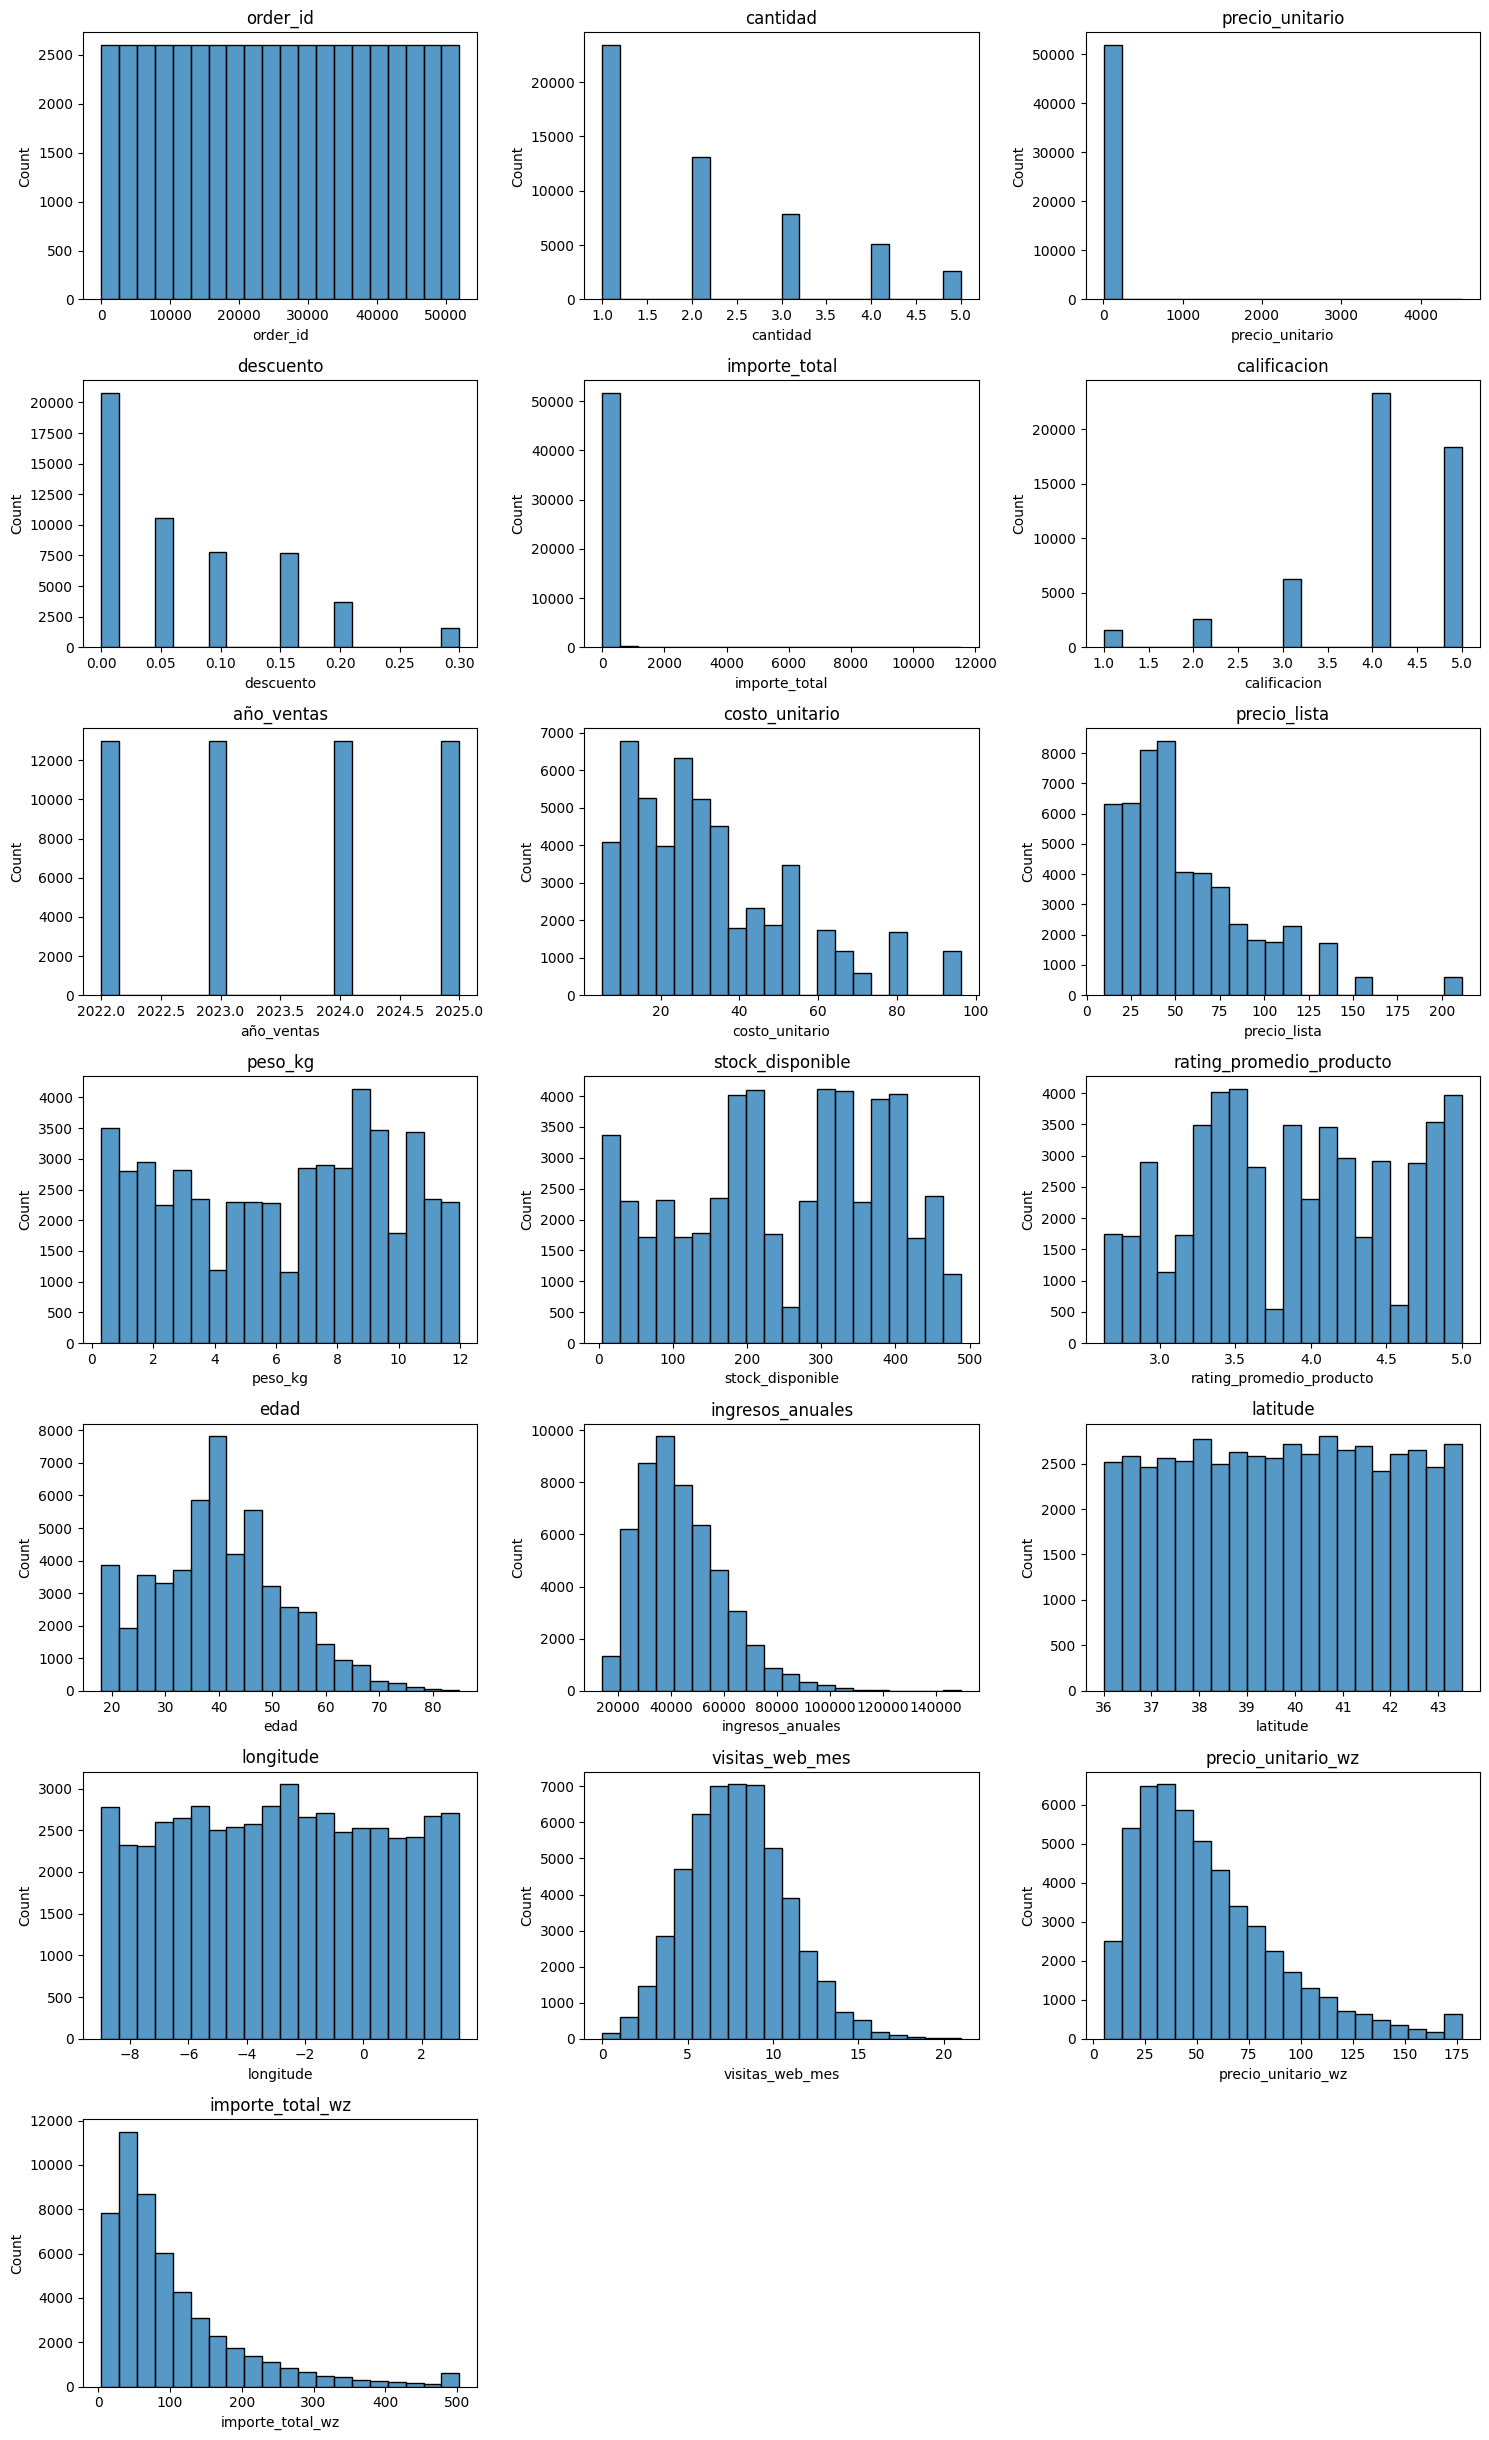


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


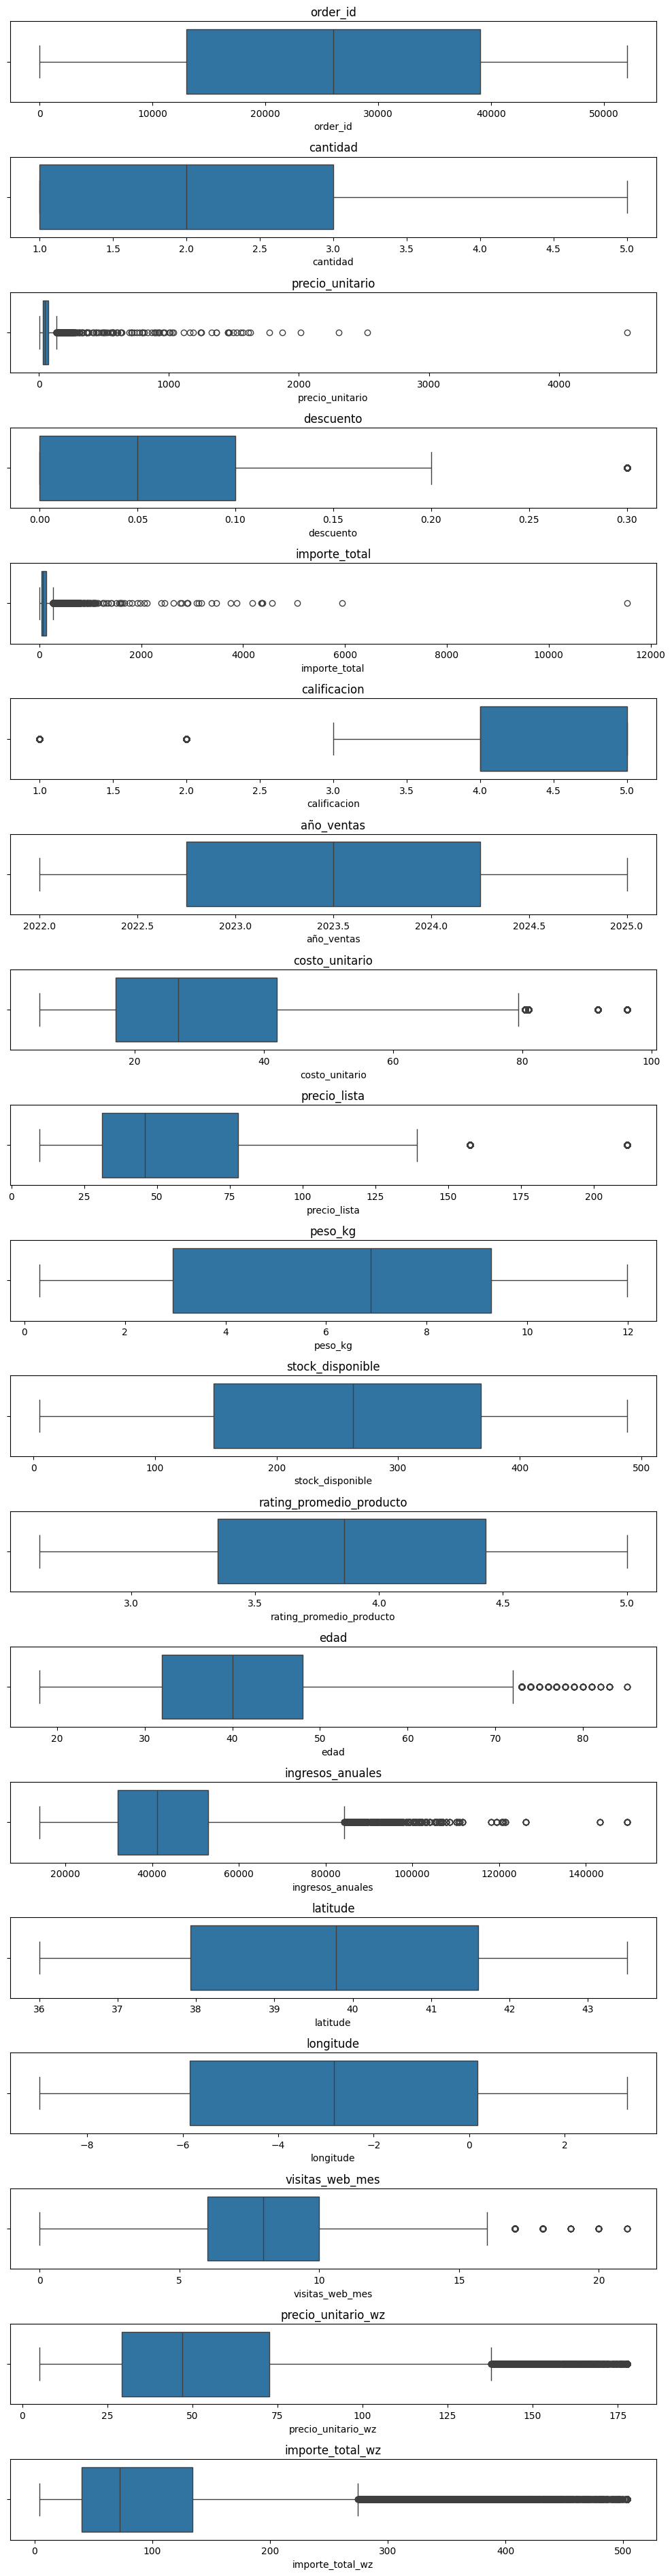

In [72]:
eda(df)

In [73]:
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude']

Variables numéricas:

 Index(['cantidad', 'precio_unitario', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

Variables categóricas:

 Index(['metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

Variables datetime:

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

Variables numéricas:
                            count      mean       std       min       25%       50%       75%        max
cantidad                  52000.0      2.05      1.20      1.00      1.00      2.00      3.00       5.00
precio_unitario           52000.0     56.44     56.

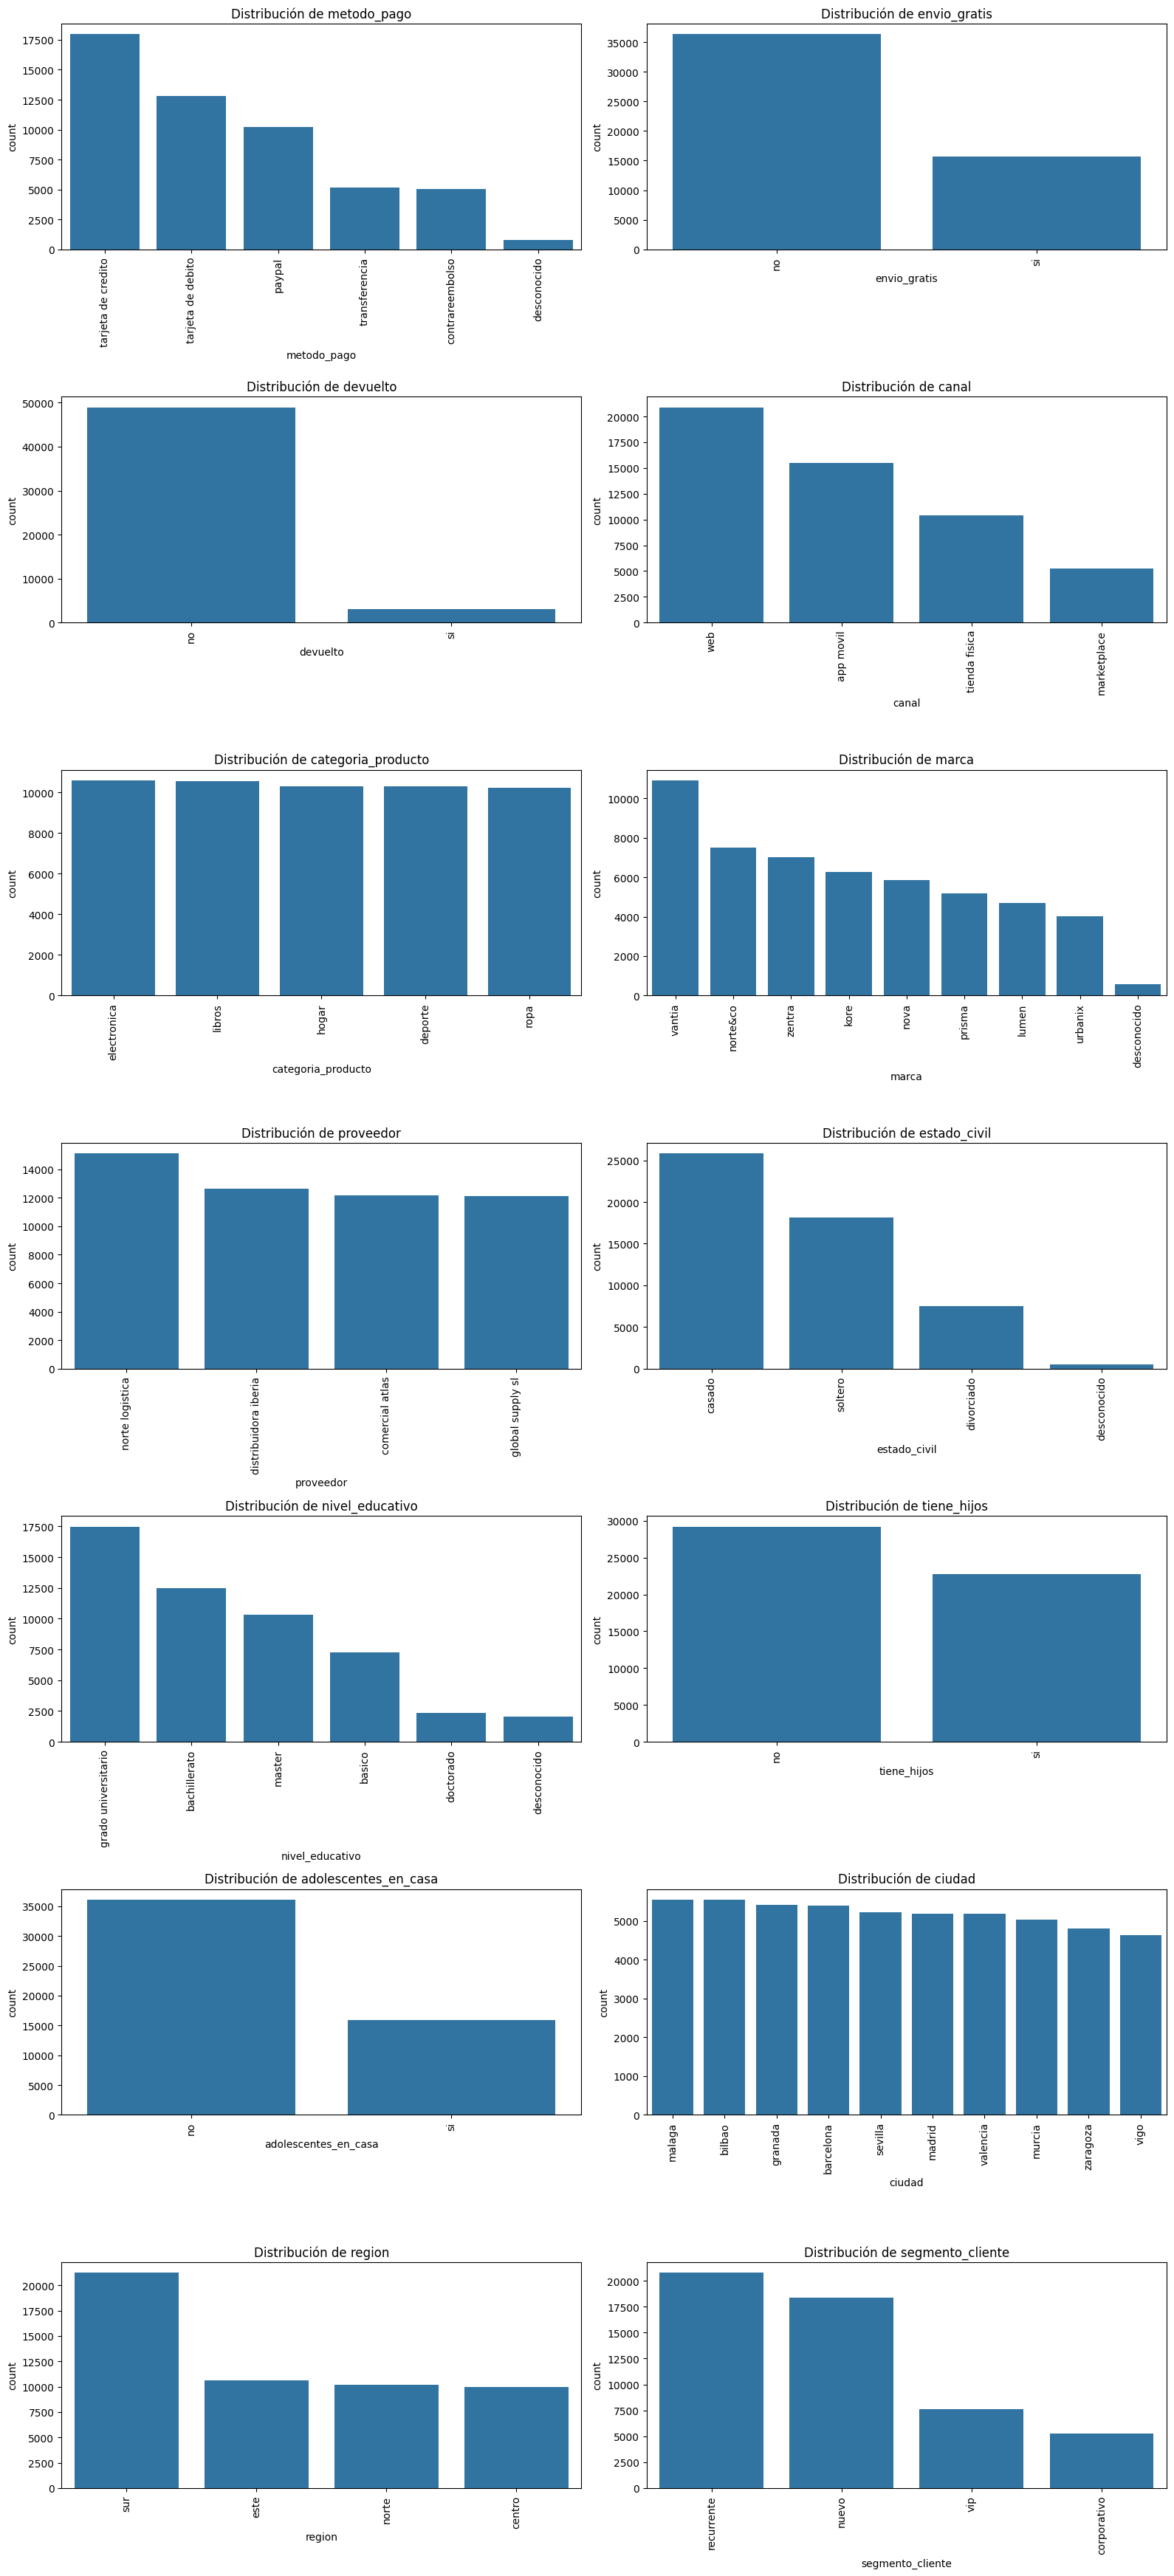


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


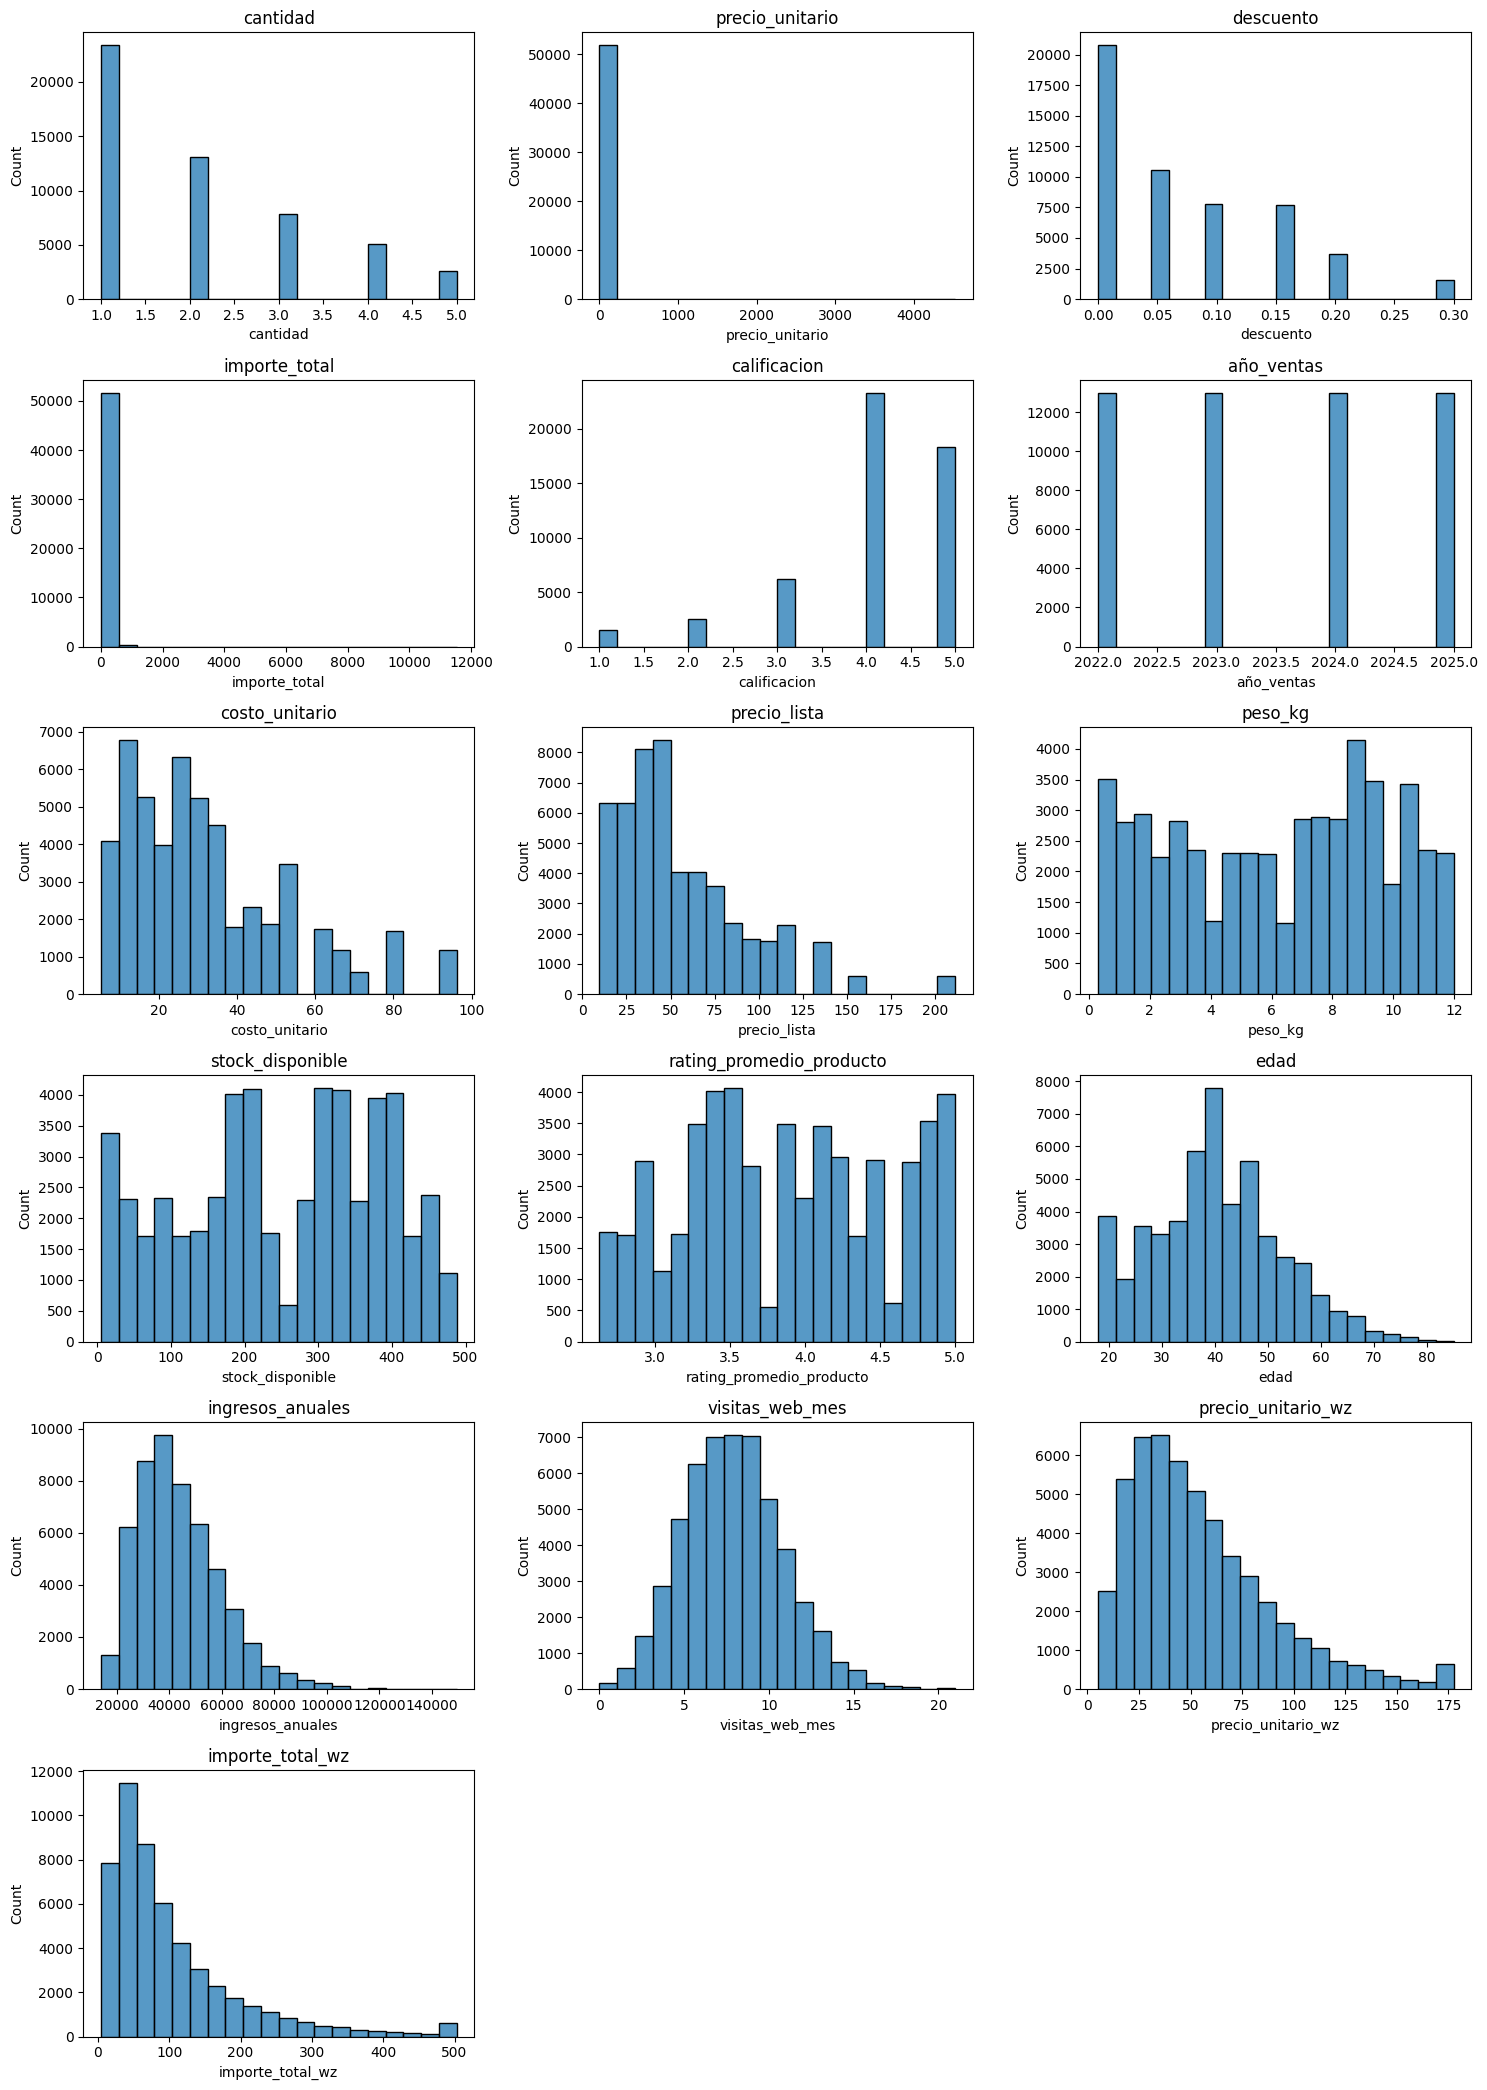


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


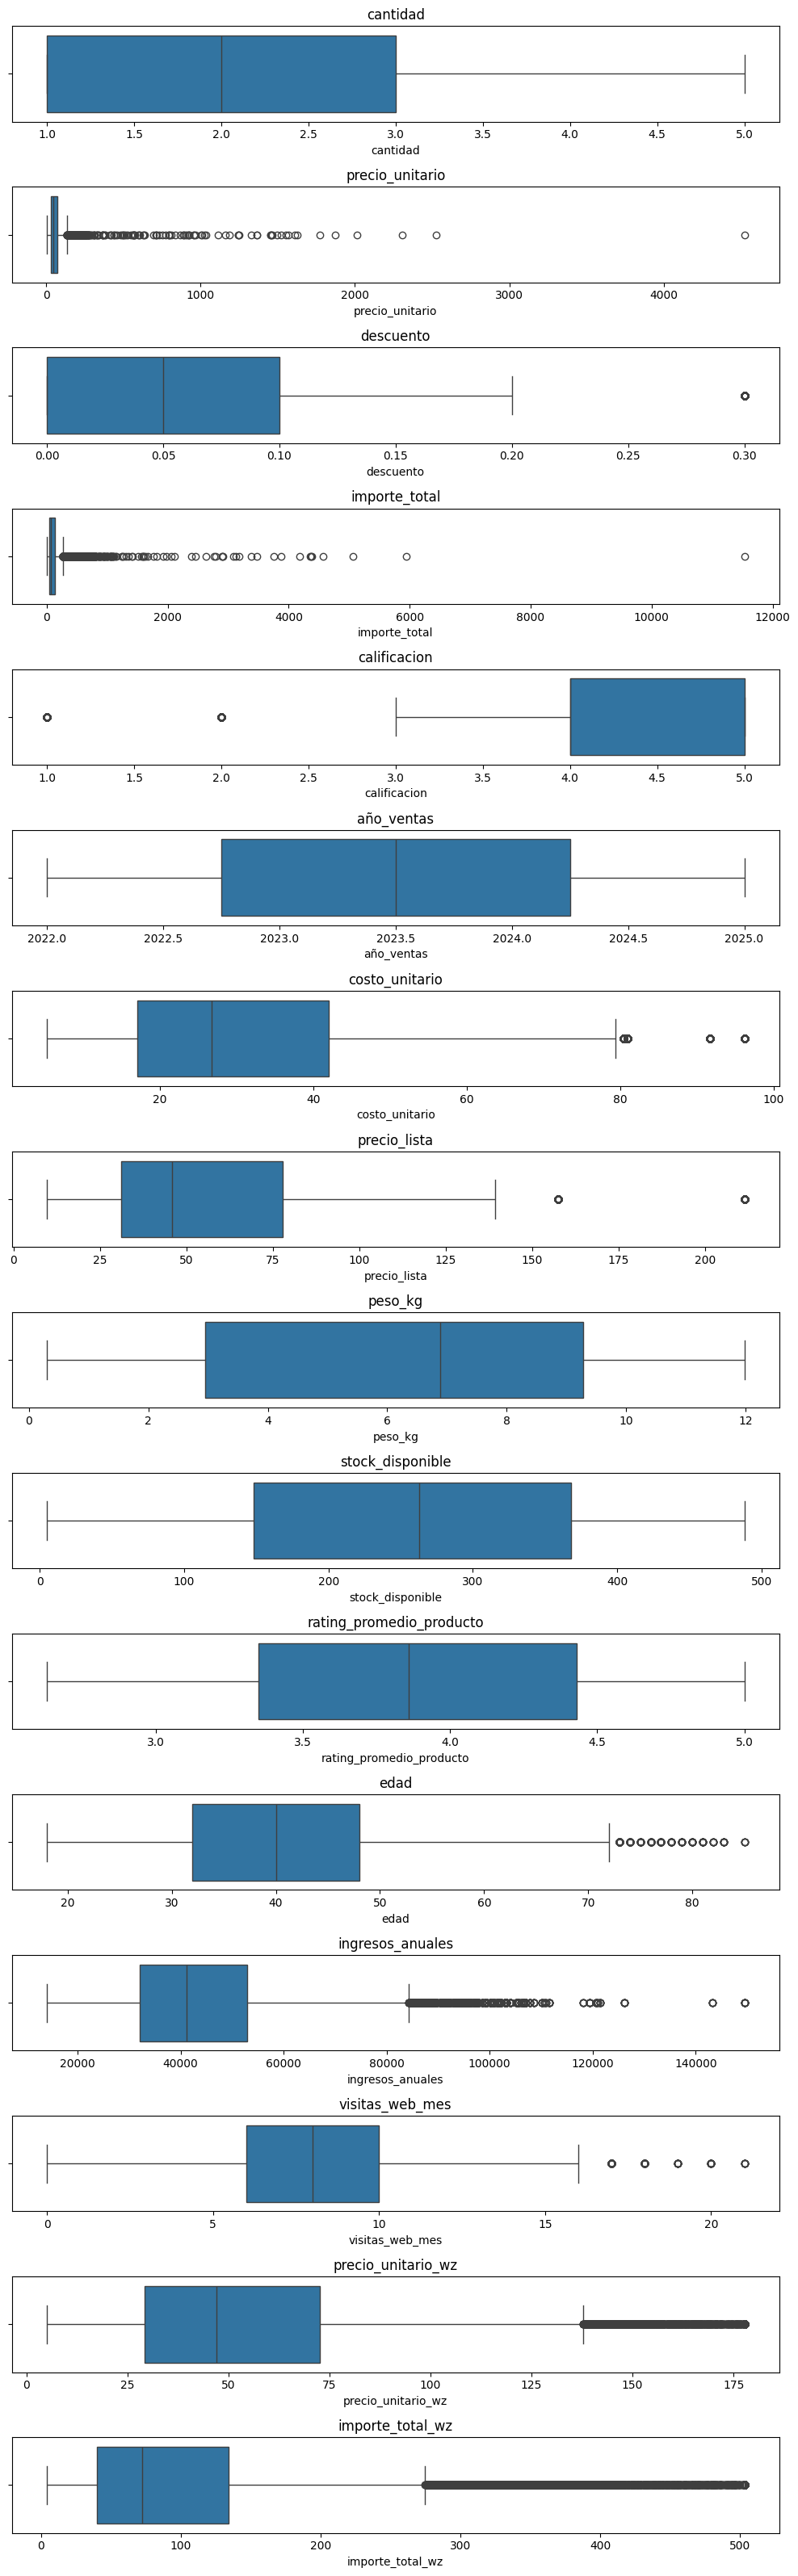

In [74]:
eda(df,cols_excluir=cols_excluir)